# NorthStar Urban Mobility and Logistics
## Notebook 2: SQL in R Analysis

This notebook uses SQL queries within R to analyse the cleaned NorthStar datasets.

The objectives of this notebook are to:

- Load cleaned datasets from GitHub.
- Store them in an SQLite database.
- Execute SQL queries within R.
- Identify operational issues such as delays, complaints, and incidents.
- Interpret the results in business terms.

This analysis supports the relational database component of the coursework.

Install Required Packages

In [ ]:
install.packages("sqldf")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [ ]:
install.packages("DBI")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("RSQLite")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Load Libraries

In [ ]:
# Load required libraries
library(DBI)
library(RSQLite)
library(sqldf)
library(ggplot2)
library(dplyr)

cat("All libraries loaded successfully.\n")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




All libraries loaded successfully.


## Set GitHub Repository URL

The cleaned datasets are loaded directly from the `cleaned_data` folder in the GitHub repository.

In [ ]:
github_username <- "haamnaaa"

# Base URL for cleaned data
base_url <- paste0(
  "https://raw.githubusercontent.com/haamnaaa/DBA-Files/main/cleaned_data/northstar_cleaned_data/"
)

cat(base_url)

https://raw.githubusercontent.com/haamnaaa/DBA-Files/main/cleaned_data/northstar_cleaned_data/

## Load Cleaned Datasets

In [ ]:
# Load datasets
orders <- read.csv(paste0(base_url, "orders_clean.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries_clean.csv"))
complaints <- read.csv(paste0(base_url, "complaints_clean.csv"))
drivers <- read.csv(paste0(base_url, "drivers_clean.csv"))
incidents <- read.csv(paste0(base_url, "incidents_clean.csv"))
hubs <- read.csv(paste0(base_url, "hubs_clean.csv"))

cat("Datasets loaded successfully.\n")

Datasets loaded successfully.


Check Dimensions

In [ ]:
# Display dimensions of each dataset
dim(orders)
dim(deliveries)
dim(complaints)
dim(drivers)
dim(incidents)
dim(hubs)

[1] 1250   11

[1] 950  13

[1] 320  10

[1] 170   8

[1] 280   7

[1] 8 5

## Create SQLite Database

The cleaned datasets are loaded into an in-memory SQLite database so SQL queries can be executed directly in R.

Create Database Connection

In [ ]:
# Create SQLite database in memory
con <- dbConnect(SQLite(), ":memory:")

cat("Database connection created.\n")

Database connection created.


Write Tables to Database

In [ ]:
# Write dataframes to SQLite tables
dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)

cat("Tables written to SQLite database.\n")

Tables written to SQLite database.


## Analysis 1: Customer Complaints by Type

In [ ]:
query1 <- "
SELECT
    complaint_type,
    COUNT(*) AS total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC;
"

result1 <- dbGetQuery(con, query1)
result1

complaint_type,total_complaints
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


Visualisation

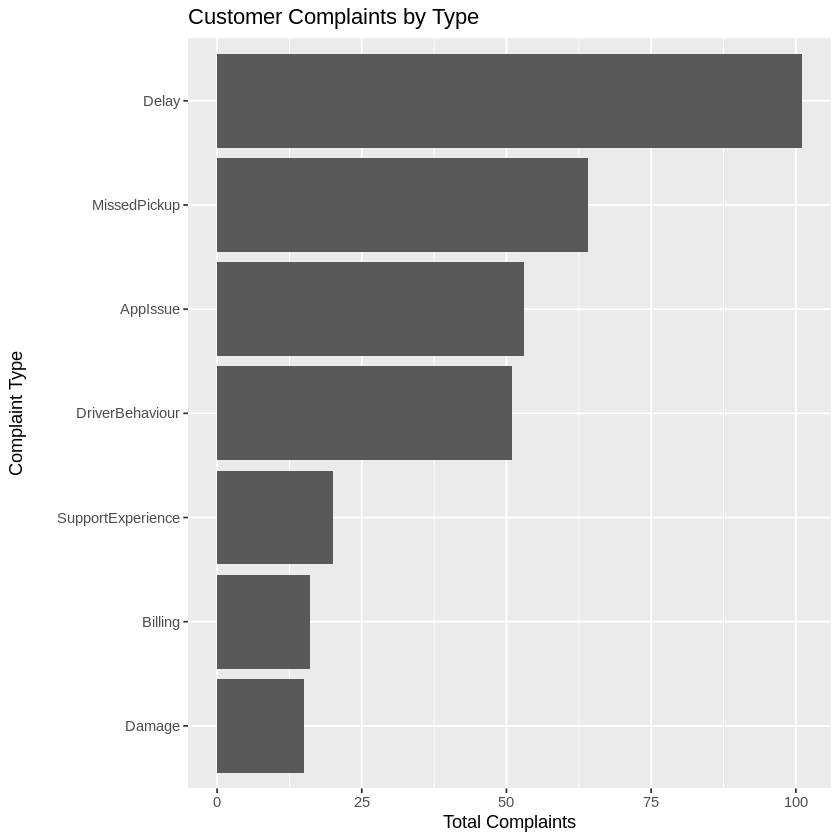

In [ ]:
ggplot(result1, aes(x = reorder(complaint_type, total_complaints), y = total_complaints)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Customer Complaints by Type",
    x = "Complaint Type",
    y = "Total Complaints"
  )

### Interpretation

This query reveals the most common reasons customers submit complaints. If late deliveries or failed service dominate, this supports the case study concern regarding declining service reliability.

## Analysis 2: Incident Severity Distribution

In [ ]:
query2 <- "
SELECT
    severity,
    COUNT(*) AS total_incidents
FROM incidents
GROUP BY severity
ORDER BY total_incidents DESC;
"

result2 <- dbGetQuery(con, query2)
result2

severity,total_incidents
<chr>,<int>
Medium,106
Low,79
High,68
Critical,27


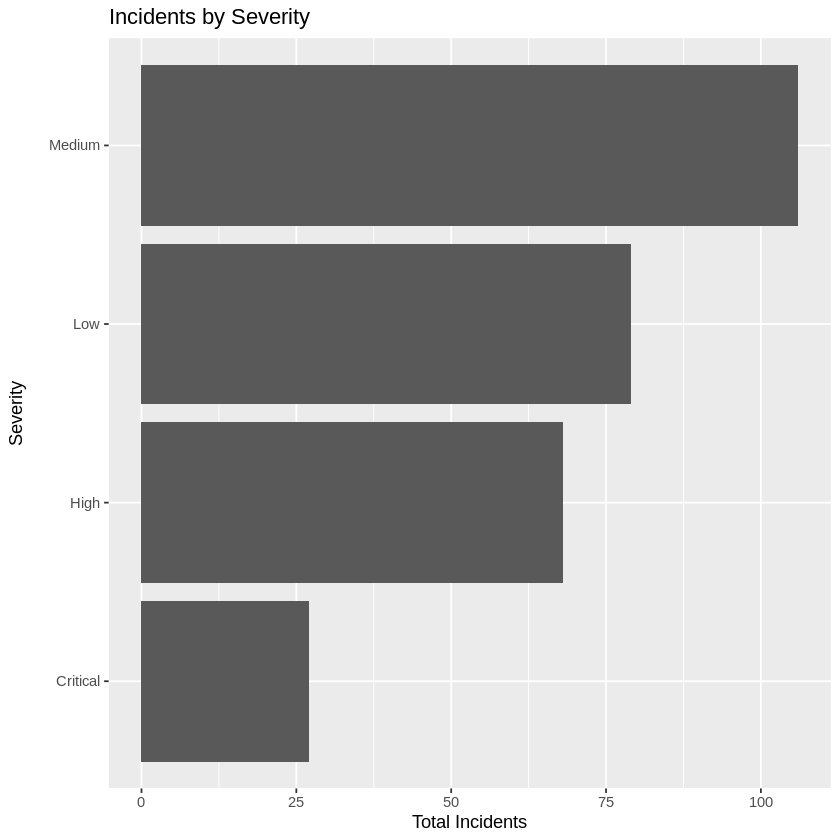

In [ ]:
ggplot(result2, aes(x = reorder(severity, total_incidents), y = total_incidents)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Incidents by Severity",
    x = "Severity",
    y = "Total Incidents"
  )

### Interpretation

A large number of high-severity incidents may indicate inadequate driver training, maintenance issues, or poor operational controls.

## Analysis 3: Complaints by Hub

In [ ]:
# SQL query to count complaints for each hub
query3 <- "
SELECT
    h.hub_id,
    h.hub_name,
    COUNT(c.complaint_id) AS total_complaints
FROM complaints c
LEFT JOIN orders o
    ON c.order_id = o.order_id
LEFT JOIN deliveries d
    ON o.order_id = d.order_id
LEFT JOIN hubs h
    ON d.hub_id = h.hub_id
GROUP BY h.hub_id, h.hub_name
ORDER BY total_complaints DESC;
"

result3 <- dbGetQuery(con, query3)
result3

hub_id,hub_name,total_complaints
<chr>,<chr>,<int>
NA,NA,88
H08,Midtown Relay,35
H03,East Dock,33
H07,Riverside Hub,33
H01,North Exchange,32
H05,Central Core,30
H04,West Gate,28
H06,Airport Hub,23
H02,South Link,18


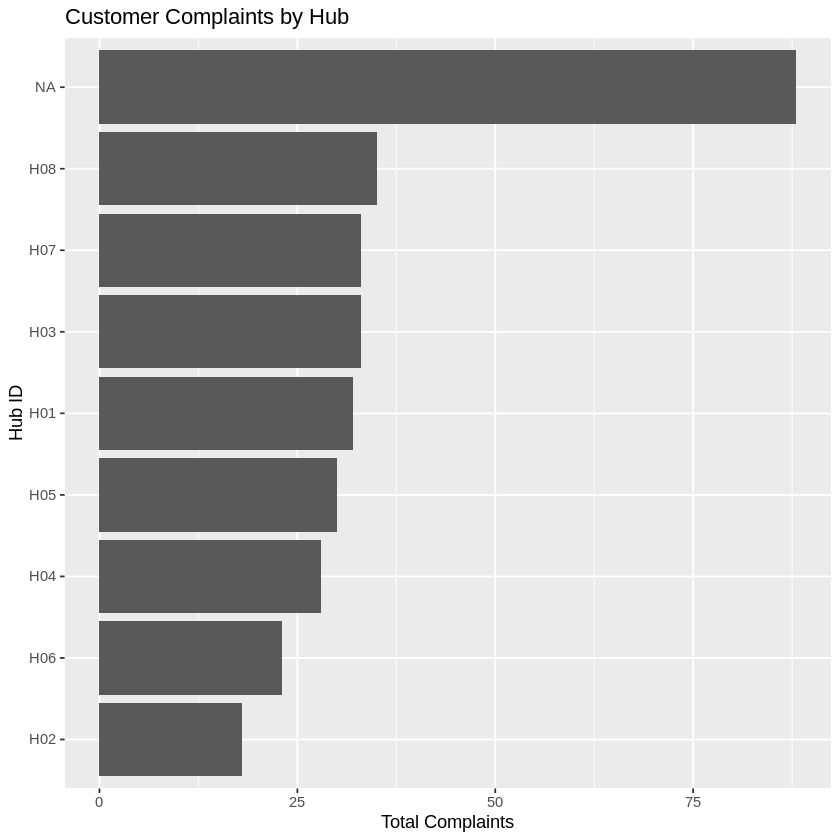

In [ ]:
ggplot(result3, aes(x = reorder(hub_id, total_complaints), y = total_complaints)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Customer Complaints by Hub",
    x = "Hub ID",
    y = "Total Complaints"
  )

### Interpretation

Hubs with significantly higher complaint volumes are likely experiencing operational bottlenecks or quality issues.

In [ ]:
query <- "
SELECT hub_id,
       COUNT(delivery_id) AS total_deliveries
FROM deliveries
GROUP BY hub_id
ORDER BY total_deliveries DESC;
"
result <- dbGetQuery(con, query)
result

hub_id,total_deliveries
<chr>,<int>
H01,136
H08,128
H04,127
H03,119
H07,115
H05,115
H02,106
H06,104


## Analysis 4: Delivery Status Distribution

In [ ]:
query4 <- "
SELECT
    delivery_status,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC;
"

result4 <- dbGetQuery(con, query4)
result4

### Interpretation

This query highlights how many deliveries were completed successfully versus delayed or failed.

In [ ]:
# Close database connection
dbDisconnect(con)

cat("Database connection closed.\n")

## Summary of SQL in R Analysis

This notebook demonstrated the use of SQL within R to analyse operational data from NorthStar.

Key findings include:

- Most common customer complaint types.
- Incident severity patterns.
- Hubs with elevated complaint volumes.

These results provide evidence of operational inefficiencies and customer service issues, supporting the broader analytical conclusions of the coursework.